用蚁群算法求解30个城市的TSP问题 \
希望对比普通蚁群算法、最大最小蚁群算法、添加2-opt优化 \
希望对比是否固定起点城市

In [155]:
import random
import numpy as np
import matplotlib.pyplot as plt
import re
from typing import List, Tuple

plt.rcParams["font.family"] = ["Microsoft YaHei"]  # 使用微软雅黑
plt.rcParams["axes.unicode_minus"] = False         # 解决负号显示问题

In [156]:
def load_data_re(file_path):
    """
    用正则表达式
    从txt文件中读取以分号分隔的城市x, y坐标, 返回城市坐标列表

    :param file_path: txt文件路径
    :return city_coords: 城市坐标列表 [(x1, y1), (x2, y2), ...]
    """
    with open(file_path, 'r') as f:
        data = f.read()

    pattern = re.compile(r'(\d+)\s+(\d+)')   # x y
    matches = pattern.findall(data)

    city_coords = []
    for city in matches:                
        x = city[0]   
        y = city[1]
        city_coords.append((float(x), float(y)))
    
    return city_coords

In [157]:
# 准备输入数据
file_path = '30城市.txt'
cities = load_data_re(file_path)
print(f'总共有{len(cities)}个城市')
print('城市坐标列表：')
print(cities)

总共有30个城市
城市坐标列表：
[(41.0, 94.0), (37.0, 84.0), (54.0, 67.0), (25.0, 62.0), (7.0, 64.0), (2.0, 99.0), (68.0, 58.0), (71.0, 44.0), (54.0, 62.0), (83.0, 69.0), (64.0, 60.0), (18.0, 54.0), (22.0, 60.0), (83.0, 46.0), (91.0, 38.0), (25.0, 38.0), (24.0, 42.0), (58.0, 69.0), (71.0, 71.0), (74.0, 78.0), (87.0, 76.0), (18.0, 40.0), (13.0, 40.0), (82.0, 7.0), (62.0, 32.0), (58.0, 35.0), (45.0, 21.0), (41.0, 26.0), (44.0, 35.0), (4.0, 50.0)]


先实现一版最基础的，选用基础蚁群算法，不固定蚂蚁出发的起点城市

第1轮: Best distance = 531.6161
第2轮: Best distance = 457.0939
第3轮: Best distance = 457.0939
第4轮: Best distance = 457.0939
第5轮: Best distance = 457.0939
第6轮: Best distance = 457.0939
第7轮: Best distance = 457.0939
第8轮: Best distance = 457.0939
第9轮: Best distance = 457.0939
第10轮: Best distance = 435.1059
第11轮: Best distance = 435.1059
第12轮: Best distance = 435.1059
第13轮: Best distance = 435.1059
第14轮: Best distance = 435.1059
第15轮: Best distance = 435.1059
第16轮: Best distance = 435.1059
第17轮: Best distance = 435.1059
第18轮: Best distance = 435.1059
第19轮: Best distance = 435.1059
第20轮: Best distance = 435.1059
第21轮: Best distance = 435.1059
第22轮: Best distance = 435.1059
第23轮: Best distance = 435.1059
第24轮: Best distance = 435.1059
第25轮: Best distance = 435.1059
第26轮: Best distance = 435.1059
第27轮: Best distance = 435.1059
第28轮: Best distance = 435.1059
第29轮: Best distance = 435.1059
第30轮: Best distance = 435.1059
第31轮: Best distance = 435.1059
第32轮: Best distance = 435.1059
第33轮: Best distan

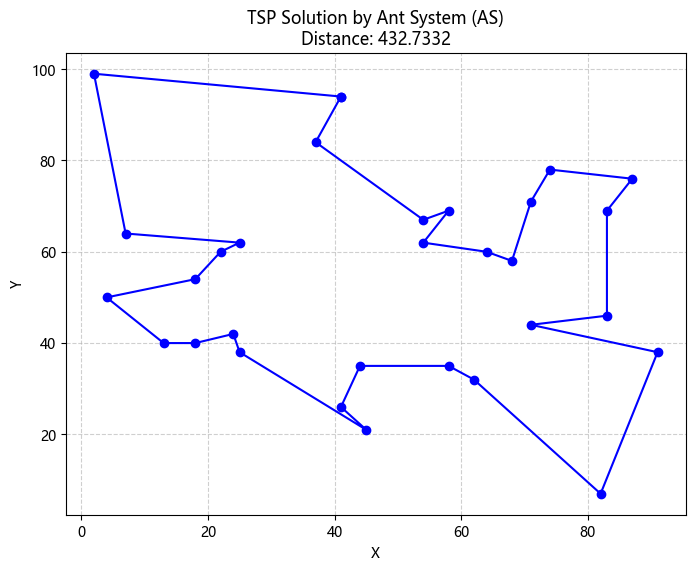

In [158]:
class AS_TSP:
    def __init__(
        self, 
        cities: List[Tuple[float, float]],
        n_ants: int = 30,
        n_iterations: int = 200,
        rho: float = 0.5,       # 信息素挥发率
        alpha: float = 1.0,     # 信息素启发因子权重
        beta: float = 5.0,      # 距离启发因子权重
        Q: float = 100          # 
    ):
        # 城市信息
        self.cities = cities 
        self.num_cities = len(cities)
        self.distance_matrix = self._compute_distance_matrix()

        # 蚁群算法超参数
        self.n_ants = n_ants
        self.n_iterations = n_iterations
        self.rho = rho 
        self.alpha = alpha
        self.beta = beta 
        self.Q = Q 

        # 初始化信息素矩阵，用城市数/一条路径的距离(可随机取，比如[0, 1, ..., 29])
        self.pheromone = self._init_pheromone()

        # 全局最优记录
        self.best_path = None
        self.best_distance = float('inf')

        # 记录每轮历史信息
        self.history = {
            'best_distance': [],
            'avg_distance': []
        }

    def _compute_distance_matrix(self):
        """计算城市距离矩阵"""
        n = self.num_cities
        dist_matrix = np.zeros((n, n))             # 初始化距离矩阵
        for i in range(n):                         # 对每个城市
            x1, y1 = self.cities[i]
            for j in range(n):                     # 计算与其他城市的距离
                if i != j:
                    x2, y2 = self.cities[j]
                    dist_matrix[i][j] = np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)
        return dist_matrix
    
    def _path_distance(self, path):
        """
        计算路径距离
        """
        distance = 0.0
        n = self.num_cities
        for i in range(n):
            city1 = path[i]
            city2 = path[(i + 1) % n]
            distance += self.distance_matrix[city1][city2]
        return distance

    def _init_pheromone(self):
        """返回初始化信息素矩阵"""
        # 用城市数/一条路径的距离(可随机取，比如[0, 1, ..., 29])
        n = self.num_cities
        init_path = [i for i in range(n)]
        distance = self._path_distance(init_path)

        return np.full((n, n), n / distance)
    
    def _select_next_city(self, cur: int, visited: set) -> int:
        """根据信息素浓度, 轮盘赌选择下一个城市"""
        unvisited = [i for i in range(self.num_cities) if i not in visited]
        if len(unvisited) == 1:
            return unvisited[0]
        
        tau = self.pheromone[cur][unvisited]   # 当前城市的邻近未访问城市的信息素
        eta = 1 / self.distance_matrix[cur][unvisited]  # 可见度 (1/距离)

        # 选择概率
        probs = (tau ** self.alpha) * (eta ** self.beta)
        probs /= probs.sum()                            # 归一化

        if len(unvisited) == 0:
            print(1)
        return np.random.choice(unvisited, p=probs)

    def _construct_solution(self) -> Tuple[list[int], float]:
        """单只蚂蚁构造路径"""
        n = self.num_cities 
        start = 0                 # 固定路径起点
        # start = random.randint(0, n-1)    # [0, n-1]
        path = [start]
        visited = {start}         # 已访问节点
        cur = start               # 当前所处城市

        for _ in range(n-1):      # 还有n-1个城市
            next = self._select_next_city(cur, visited)
            path.append(next)
            visited.add(next)
            cur = next 

        return path, self._path_distance(path)

    def _update_pheromone(self, all_paths, all_distances):
        # 信息素挥发
        self.pheromone *= (1-self.rho)

        # 信息素更新
        for path, dist in zip(all_paths, all_distances):
            # 蚁周模型
            # 如果 蚂蚁k本次经过子路径ij，对它增加信息素Q/蚂蚁k的总路径
            delta_tau = self.Q / dist   
            for i in range(self.num_cities):
                u = path[i]
                v = path[(i+1) % self.num_cities]
                self.pheromone[u][v] += delta_tau 
                self.pheromone[v][u] += delta_tau 

    def run(self) -> Tuple[List[int], float]:
        for iter in range(self.n_iterations):
            # 记录当轮所有蚂蚁的路径
            all_paths = []
            all_distances = []

            for _ in range(self.n_ants):
                path, distance = self._construct_solution()
                all_paths.append(path)
                all_distances.append(distance)
            
            # 每轮记录信息
            iter_best_distance = min(all_distances)
            iter_avg_distance = np.mean(all_distances)
            self.history['best_distance'].append(iter_best_distance) 
            self.history['avg_distance'].append(iter_avg_distance)

            # 更新全局最优
            min_idx = int(np.argmin(all_distances))
            if all_distances[min_idx] < self.best_distance:
                self.best_path = all_paths[min_idx].copy()
                self.best_distance = all_distances[min_idx]
            
            # 更新信息素
            self._update_pheromone(all_paths, all_distances)

            print(f"第{iter+1}轮: Best distance = {self.best_distance:.4f}")

        return self.best_path, self.best_distance

    def plot_path(self):
        x = [self.cities[i][0] for i in self.best_path]
        y = [self.cities[i][1] for i in self.best_path]
        x.append(x[0])  # 回到起点
        y.append(y[0])

        plt.figure(figsize=(8, 6))
        plt.plot(x, y, 'b-o', markersize=6, linewidth=1.5)
        plt.title(f"TSP Solution by Ant System (AS)\nDistance: {self.best_distance:.4f}")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()


as_tsp = AS_TSP(
    cities=cities, 
    n_ants=30,
    n_iterations=100,
    rho=0.6, 
    alpha=1,
    beta=5,
    Q=100
)

best_path, best_dist = as_tsp.run()

print("\n✅ 最优路径:", best_path)
print("📏 最短距离:", f"{best_dist:.4f}")

# 可视化结果
as_tsp.plot_path()

第1轮: Best distance = 507.1344
第2轮: Best distance = 466.2262
第3轮: Best distance = 458.5902
第4轮: Best distance = 431.2675
第5轮: Best distance = 431.2675
第6轮: Best distance = 426.5438
第7轮: Best distance = 426.5438
第8轮: Best distance = 426.5438
第9轮: Best distance = 426.5438
第10轮: Best distance = 425.8201
第11轮: Best distance = 425.8201
第12轮: Best distance = 425.8201
第13轮: Best distance = 425.8201
第14轮: Best distance = 425.6490
第15轮: Best distance = 425.6490
第16轮: Best distance = 425.6490
第17轮: Best distance = 425.6490
第18轮: Best distance = 425.6490
第19轮: Best distance = 425.6490
第20轮: Best distance = 425.6490
第21轮: Best distance = 425.6490
第22轮: Best distance = 425.6490
第23轮: Best distance = 425.6490
第24轮: Best distance = 425.6490
第25轮: Best distance = 425.6490
第26轮: Best distance = 425.6490
第27轮: Best distance = 425.6490
第28轮: Best distance = 425.6490
第29轮: Best distance = 425.6490
第30轮: Best distance = 425.6490
第31轮: Best distance = 425.6490
第32轮: Best distance = 425.6490
第33轮: Best distan

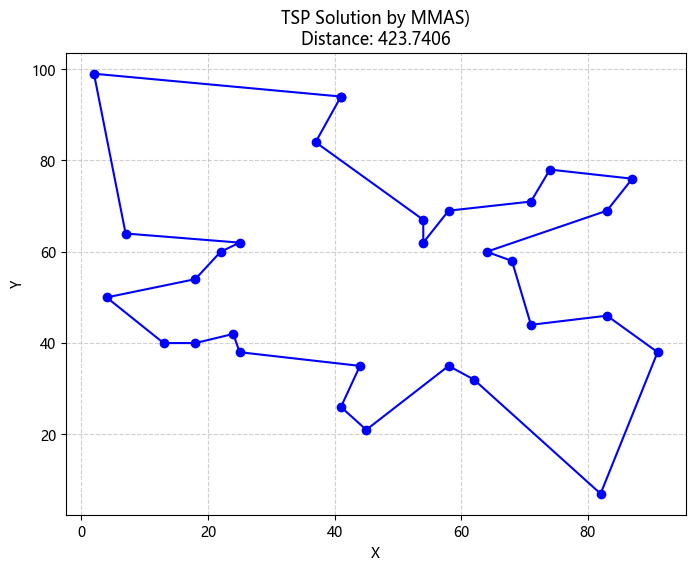

In [ ]:
# 最大最小蚂蚁系统
# 只有最优解（可设为全局）所属路径上的信息被更新
# 为避免过早收敛，将每条路径可能的信息素限制于[tau_min, tau_max]

class MMAS_TSP:
    def __init__(
        self, 
        cities: List[Tuple[float, float]],
        n_ants: int = 30,
        n_iterations: int = 200,
        rho: float = 0.5,       # 信息素挥发率
        alpha: float = 1.0,     # 信息素启发因子权重
        beta: float = 5.0,      # 距离启发因子权重
        Q: float = 100,         # 
    ):
        # 城市信息
        self.cities = cities 
        self.num_cities = len(cities)
        self.distance_matrix = self._compute_distance_matrix()

        # 蚁群算法超参数
        self.n_ants = n_ants
        self.n_iterations = n_iterations
        self.rho = rho 
        self.alpha = alpha
        self.beta = beta 
        self.Q = Q 

        # 初始化信息素矩阵
        # 初始化信息素上下限
        self.tau_min = 0.0
        self.tau_max = 0.0
        self.pheromone = None 

        # 全局最优记录
        self.best_path = None
        self.best_distance = float('inf')

        # 记录每轮历史信息
        self.history = {
            'best_distance': [],
            'avg_distance': []
        }

    def _compute_distance_matrix(self):
        """计算城市距离矩阵"""
        n = self.num_cities
        dist_matrix = np.zeros((n, n))             # 初始化距离矩阵
        for i in range(n):                         # 对每个城市
            x1, y1 = self.cities[i]
            for j in range(n):                     # 计算与其他城市的距离
                if i != j:
                    x2, y2 = self.cities[j]
                    dist_matrix[i][j] = np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)
        return dist_matrix
    
    def _path_distance(self, path):
        """
        计算路径距离
        """
        distance = 0.0
        n = self.num_cities
        for i in range(n):
            city1 = path[i]
            city2 = path[(i + 1) % n]
            distance += self.distance_matrix[city1][city2]
        return distance

    def _init_pheromone(self):
        """初始化信息素上下限+矩阵"""
        # 用城市数/一条路径的距离(可随机取，比如[0, 1, ..., 29])
        n = self.num_cities
        init_path = [i for i in range(n)]
        distance = self._path_distance(init_path)

        self.tau_max = 1 / (self.rho * distance)
        self.tau_min = self.tau_max / (2 * n)
        self.pheromone = np.full((n, n), self.tau_max)
    
    def _select_next_city(self, cur: int, visited: set) -> int:
        """根据信息素浓度, 轮盘赌选择下一个城市"""
        unvisited = [i for i in range(self.num_cities) if i not in visited]
        if len(unvisited) == 1:
            return unvisited[0]
        
        tau = self.pheromone[cur][unvisited]   # 当前城市的邻近未访问城市的信息素
        eta = 1 / self.distance_matrix[cur][unvisited]  # 可见度 (1/距离)

        # 选择概率
        probs = (tau ** self.alpha) * (eta ** self.beta)
        probs /= probs.sum()                            # 归一化

        if len(unvisited) == 0:
            print(1)
        return np.random.choice(unvisited, p=probs)

    def _construct_solution(self) -> Tuple[list[int], float]:
        """单只蚂蚁构造路径"""
        n = self.num_cities 
        start = 0                 # 固定路径起点
        # start = random.randint(0, n-1)    # [0, n-1]
        path = [start]
        visited = {start}         # 已访问节点
        cur = start               # 当前所处城市

        for _ in range(n-1):      # 还有n-1个城市
            next = self._select_next_city(cur, visited)
            path.append(next)
            visited.add(next)
            cur = next 

        return path, self._path_distance(path)

    def _update_pheromone(self):
        """用全局最优路径更新信息素"""
        # 信息素挥发
        self.pheromone *= (1-self.rho)

        # 蚁周模型
        # 如果 蚂蚁k本次经过子路径ij，对它增加信息素Q/蚂蚁k的总路径
        delta_tau = self.Q / self.best_distance   
        for i in range(self.num_cities):
            u = self.best_path[i]
            v = self.best_path[(i+1) % self.num_cities]
            self.pheromone[u][v] += delta_tau 
            self.pheromone[v][u] += delta_tau

        # 限制信息素范围
        self.pheromone = np.clip(self.pheromone, self.tau_min, self.tau_max) 

    def run(self) -> Tuple[List[int], float]:
        self._init_pheromone()
        
        for iter in range(self.n_iterations):
            # 记录当轮所有蚂蚁的路径
            all_paths = []
            all_distances = []

            for _ in range(self.n_ants):
                path, distance = self._construct_solution()
                all_paths.append(path)
                all_distances.append(distance)
            
            # 每轮记录信息
            iter_best_distance = min(all_distances)
            iter_avg_distance = np.mean(all_distances)
            self.history['best_distance'].append(iter_best_distance) 
            self.history['avg_distance'].append(iter_avg_distance)
            
            # 更新全局最优
            min_idx = int(np.argmin(all_distances))
            if all_distances[min_idx] < self.best_distance:
                self.best_path = all_paths[min_idx].copy()
                self.best_distance = all_distances[min_idx]
            
            # 更新信息素
            self._update_pheromone()

            print(f"第{iter+1}轮: Best distance = {self.best_distance:.4f}")

        return self.best_path, self.best_distance

    def plot_path(self):
        x = [self.cities[i][0] for i in self.best_path]
        y = [self.cities[i][1] for i in self.best_path]
        x.append(x[0])  # 回到起点
        y.append(y[0])

        plt.figure(figsize=(8, 6))
        plt.plot(x, y, 'b-o', markersize=6, linewidth=1.5)
        plt.title(f"TSP Solution by MMAS)\nDistance: {self.best_distance:.4f}")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()


mmas_tsp = MMAS_TSP(
    cities=cities, 
    n_ants=30,
    n_iterations=100,
    rho=0.4, 
    alpha=1,
    beta=5,
    Q=100
)

best_path, best_dist = mmas_tsp.run()

print("\n✅ 最优路径:", best_path)
print("📏 最短距离:", f"{best_dist:.4f}")

# 可视化结果
mmas_tsp.plot_path()

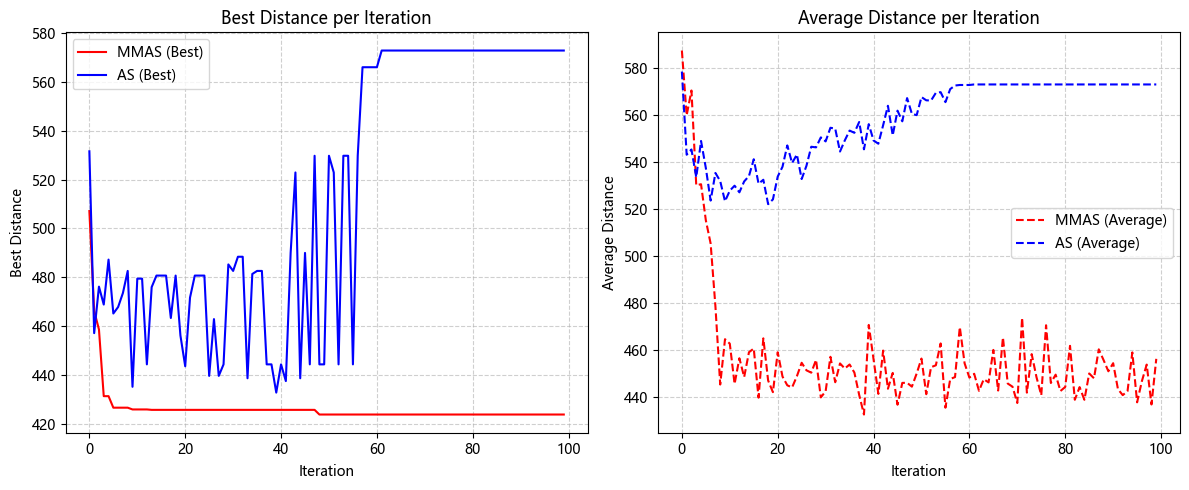

In [160]:
plt.figure(figsize=(12, 5))

# 图1：每轮最优距离
plt.subplot(1, 2, 1)
plt.plot(mmas_tsp.history['best_distance'], label='MMAS (Best)', color='red')
plt.plot(as_tsp.history['best_distance'], label='AS (Best)', color='blue')
plt.xlabel('Iteration')
plt.ylabel('Best Distance')
plt.title('Best Distance per Iteration')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 图2：每轮平均距离
plt.subplot(1, 2, 2)
plt.plot(mmas_tsp.history['avg_distance'], label='MMAS (Average)', color='red', linestyle='--')
plt.plot(as_tsp.history['avg_distance'], label='AS (Average)', color='blue', linestyle='--')
plt.xlabel('Iteration')
plt.ylabel('Average Distance')
plt.title('Average Distance per Iteration')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()